In [295]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
import speech_recognition as sr
from pydub import AudioSegment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
from wordcloud import WordCloud
from collections import Counter
import re

Movilizaciones 2022 -2024

In [296]:
base_mov = pd.read_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Rutas_puntos_críticos/moviliz_sociales_2022_2024.csv', sep =';', encoding='latin')

base_mov.head(2)

,Id_Evento,Nombre_Evento,Localidad,Dirección_Inicio,Fecha_Inicio,Hora_Inicio,Convocante,Categoría_Tipo_Evento,Tipo_Evento,Tipo_ Acompanamiento,...,Intervencion_ Gufud,Intervencion_ UNDMO,Etapa_ Escala,Etapa_ Final,Entidades_ Acompanantes,Periodo,Mes,Dia,Interv_Fuerza_ Disponible,Intervencion_Esmad
0,-11806,ACOMPAÑAMIENTO VÍCTIMAS DEL CONFLICTO ARMADO F...,CHAPINERO,"Ak. 7 #63-44, Bogotá, Colombia",15/02/2022,"0,291666667",ACTOR SOCIAL NO IDENTIFICADO - SECTOR VÍCTIMAS...,Movilización Social,Concentración /Estática,Plantón,...,0,0,Fomento del Diálogo Social: Interlocución con ...,Fomento del Diálogo Social: Interlocución con ...,Secretaría Distrital de Gobierno,2022,2,15,0,0
1,-11805,ACOMPAÑAMIENTO COMUNIDAD EMBERA UPI FLORIDA AM,ENGATIVÁ,"Parque Regional La Florida, Cl 64, Cota, Cundi...",15/02/2022,"0,291666667",COMUNIDAD EMBERA KATIO Y EMBERA CHAMÍ (NO USAR),Movilización Social,Concentración /Estática,Plantón,...,0,0,Fomento del Diálogo Social: Interlocución con ...,Fomento del Diálogo Social: Interlocución con ...,Secretaría Distrital de Gobierno,2022,2,15,0,0


In [297]:
#imprortar paradas

paradas = pd.read_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Paraderos_Zonales_del_SITP.csv')

paradas.head(3)

,X,Y,objectid,cenefa,zona_sitp,nombre,via,direccion_bandera,localidad,longitud,latitud,consecutivo_zona,tipo_m_s,consola,panel,audio,zonas_nuevas,globalid,shape
0,1.001502e+06,1.010205e+06,1,001A00,00,C.C. Iserra 100,AC 100,AC 100 - KR 54,Barrios Unidos,-74.063971,4.688481,001,M,AC 100 - KR 54 (001A00),AC 100 - KR 54,Avenida Calle 100 Carrera 54,C,{1C0DBC4E-15BC-4BBE-BC16-5628077DBE2E},NaN
1,1.003505e+06,1.009719e+06,2,001A01,01,Br. Rincón del Chicó,AC 100,AC 100 - KR 13,Usaquén,-74.045914,4.684091,001,M,AC 100 - KR 13 (001A01),AC 100 - KR 13,Avenida Calle 100 Carrera 13,B,{60A22A44-AD56-4DF4-A3E6-6830B9FB0792},NaN
2,1.001238e+06,1.018098e+06,3,001A02,02,Gimnasio Iragua,AV. Boyacá,AV. Boyacá - AC 170,Suba,-74.066350,4.759867,001,S,AV. Boyacá - AC 170 (001A02),AV. Boyacá - AC 170,Avenida Boyacá Avenida Calle 170,C,{97155274-E4D5-45A4-891F-2DCA19FF10D9},NaN


In [298]:
#cruzar datos de paradas con paradas de la bitácora

maestro_paradas = paradas[[
    "cenefa",
    "nombre",
    "via",
    "direccion_bandera",
    "localidad",
    "longitud",
    "latitud"
]]

maestro_paradas.head()

,cenefa,nombre,via,direccion_bandera,localidad,longitud,latitud
0,001A00,C.C. Iserra 100,AC 100,AC 100 - KR 54,Barrios Unidos,-74.063971,4.688481
1,001A01,Br. Rincón del Chicó,AC 100,AC 100 - KR 13,Usaquén,-74.045914,4.684091
2,001A02,Gimnasio Iragua,AV. Boyacá,AV. Boyacá - AC 170,Suba,-74.066350,4.759867
3,001A03,Br. Julio Flórez,AC 100,AC 100 - KR 66A,Suba,-74.071439,4.689504
4,001A04,Avenida Calle 80,AK 68,AK 68 - CL 79D,Barrios Unidos,-74.080392,4.682626


Movilizaciones 2022

In [299]:
movilizaciones = pd.read_excel('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Rutas_puntos_críticos/novedades_2022.xlsx')

In [300]:
movilizaciones.head()

,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,TituloTotalEmpresa,TotalEmpresa,TituloTotal,Total,Mes
0,GMOVIL ENGATIVA,1/01/2022 2:16,[1083] 402,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,"Autorización desvío, ID: 132, 01-01-2022, 03:0...",NaN,Número de notas creadas por la empresa GMOVIL ...,61,Número de notas totales:,61,enero
1,GMOVIL ENGATIVA,1/01/2022 2:17,[1083] 402,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,"Autorización desvío, ID: 1175, 01-01-2022, 03:...",NaN,Número de notas creadas por la empresa GMOVIL ...,61,Número de notas totales:,61,enero
2,GMOVIL ENGATIVA,1/01/2022 2:17,[1208] 576,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,"Autorización desvío, ID: 13308, 01-01-2022, 03...",NaN,Número de notas creadas por la empresa GMOVIL ...,61,Número de notas totales:,61,enero
3,GMOVIL ENGATIVA,1/01/2022 2:18,[1208] 576,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,"Autorización desvío, ID: 9355, 01-01-2022, 03:...",NaN,Número de notas creadas por la empresa GMOVIL ...,61,Número de notas totales:,61,enero
4,GMOVIL ENGATIVA,1/01/2022 2:20,[1208] 576,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,"Autorización desvío, ID: 9682, 01-01-2022, 11:...",NaN,Número de notas creadas por la empresa GMOVIL ...,61,Número de notas totales:,61,enero


In [301]:
movilizaciones[['Línea', 'ruta_comercial']] = movilizaciones['Linea'].str.extract(r'\[(\d+)\]\s*(.*)')

movilizaciones.head()

,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,TituloTotalEmpresa,TotalEmpresa,TituloTotal,Total,Mes,Línea,ruta_comercial
0,GMOVIL ENGATIVA,1/01/2022 2:16,[1083] 402,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,"Autorización desvío, ID: 132, 01-01-2022, 03:0...",NaN,Número de notas creadas por la empresa GMOVIL ...,61,Número de notas totales:,61,enero,1083,402
1,GMOVIL ENGATIVA,1/01/2022 2:17,[1083] 402,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,"Autorización desvío, ID: 1175, 01-01-2022, 03:...",NaN,Número de notas creadas por la empresa GMOVIL ...,61,Número de notas totales:,61,enero,1083,402
2,GMOVIL ENGATIVA,1/01/2022 2:17,[1208] 576,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,"Autorización desvío, ID: 13308, 01-01-2022, 03...",NaN,Número de notas creadas por la empresa GMOVIL ...,61,Número de notas totales:,61,enero,1208,576
3,GMOVIL ENGATIVA,1/01/2022 2:18,[1208] 576,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,"Autorización desvío, ID: 9355, 01-01-2022, 03:...",NaN,Número de notas creadas por la empresa GMOVIL ...,61,Número de notas totales:,61,enero,1208,576
4,GMOVIL ENGATIVA,1/01/2022 2:20,[1208] 576,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,"Autorización desvío, ID: 9682, 01-01-2022, 11:...",NaN,Número de notas creadas por la empresa GMOVIL ...,61,Número de notas totales:,61,enero,1208,576


In [302]:
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFD', texto)
    texto = texto.encode('ascii', 'ignore').decode('utf-8')
    return texto

movilizaciones['obs_normalizada'] = movilizaciones['Observaciones'].apply(normalizar_texto)

In [303]:
patron = r'tm-?07|manifes'

movilizaciones_tm = movilizaciones[
    movilizaciones['obs_normalizada'].str.contains(patron, regex=True, na=False)
]

movilizaciones_tm.head()

,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,TituloTotalEmpresa,TotalEmpresa,TituloTotal,Total,Mes,Línea,ruta_comercial,obs_normalizada
162,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1210,577,autorizacion de desvio / 05-01-2022 /id 113a06...
163,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1210,577,autorizacion de desvio / 05-01-2022 /id 11267/...
164,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1215,806,autorizacion de desvio / 05-01-2022 /id 11346/...
165,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11280/...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1215,806,autorizacion de desvio / 05-01-2022 /id 11280/...
166,GMOVIL ENGATIVA,5/01/2022 18:30,[1216] C101,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11318/...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1216,C101,autorizacion de desvio / 05-01-2022 /id 11318/...


In [304]:
movilizaciones_tm['Observaciones_limpia'] = (
    movilizaciones_tm['Observaciones']
    .str.encode('latin1', errors='ignore')
    .str.decode('utf-8', errors='ignore')
)

movilizaciones_tm.head(3)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1977993562.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm['Observaciones_limpia'] = (


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,TituloTotalEmpresa,TotalEmpresa,TituloTotal,Total,Mes,Línea,ruta_comercial,obs_normalizada,Observaciones_limpia
162,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1210,577,autorizacion de desvio / 05-01-2022 /id 113a06...,Autorizacin de Desvo / 05-01-2022 /ID 113A06/ ...
163,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1210,577,autorizacion de desvio / 05-01-2022 /id 11267/...,Autorizacin de Desvo / 05-01-2022 /ID 11267/ 1...
164,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1215,806,autorizacion de desvio / 05-01-2022 /id 11346/...,Autorizacin de Desvo / 05-01-2022 /ID 11346/ 1...


In [305]:

movilizaciones_tm['segmentos'] = movilizaciones_tm['Observaciones_limpia'].str.split('/')

movilizaciones_tm.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\4189875007.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm['segmentos'] = movilizaciones_tm['Observaciones_limpia'].str.split('/')


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,TituloTotalEmpresa,TotalEmpresa,TituloTotal,Total,Mes,Línea,ruta_comercial,obs_normalizada,Observaciones_limpia,segmentos
162,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1210,577,autorizacion de desvio / 05-01-2022 /id 113a06...,Autorizacin de Desvo / 05-01-2022 /ID 113A06/ ...,"[Autorizacin de Desvo , 05-01-2022 , ID 113A0..."
163,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1210,577,autorizacion de desvio / 05-01-2022 /id 11267/...,Autorizacin de Desvo / 05-01-2022 /ID 11267/ 1...,"[Autorizacin de Desvo , 05-01-2022 , ID 11267..."
164,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1215,806,autorizacion de desvio / 05-01-2022 /id 11346/...,Autorizacin de Desvo / 05-01-2022 /ID 11346/ 1...,"[Autorizacin de Desvo , 05-01-2022 , ID 11346..."
165,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11280/...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1215,806,autorizacion de desvio / 05-01-2022 /id 11280/...,Autorizacin de Desvo / 05-01-2022 /ID 11280/ 1...,"[Autorizacin de Desvo , 05-01-2022 , ID 11280..."
166,GMOVIL ENGATIVA,5/01/2022 18:30,[1216] C101,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11318/...,NaN,Número de notas creadas por la empresa GMOVIL ...,117,Número de notas totales:,117,enero,1216,C101,autorizacion de desvio / 05-01-2022 /id 11318/...,Autorizacin de Desvo / 05-01-2022 /ID 11318/ 1...,"[Autorizacin de Desvo , 05-01-2022 , ID 11318..."


In [306]:
segmentos_expandidos = movilizaciones_tm['segmentos'].apply(
    lambda x: [i.strip() for i in x] if isinstance(x, list) else []
)

max_segmentos = segmentos_expandidos.apply(len).max()

for i in range(max_segmentos):
    movilizaciones_tm[f'campo_{i+1}'] = segmentos_expandidos.apply(
        lambda x: x[i] if len(x) > i else None
    )
    
movilizaciones_tm.head(3)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1062913645.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm[f'campo_{i+1}'] = segmentos_expandidos.apply(
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1062913645.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm[f'campo_{i+1}'] = segmentos_expandidos.apply(
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1062913645.py:8: SettingWithCopyWarning: 
A value is trying to be set on a cop

,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,campo_8,campo_9,campo_10,campo_11,campo_12,campo_13,campo_14,campo_15,campo_16,campo_17
162,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,"Calle 49B bis sur con carrera 5U, Sentido occ...",Paradas: Entre 128A12 - Hasta 245A12,Tomar calle 50 sur y retoma en carrera 5B,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None
163,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,"Calle 49B bis sur con carrera 5U, Sentido or...",Paradas: Entre 248A12 - Hasta 004A12,Tomar calle 49A sur y retoma en AV Caracas,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None
164,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,"Calle 49B bis sur con carrera 5U, Sentido occ...",Paradas: Entre 363A11 - Hasta 274A12,Tomar carrera 9 y calle 49B bis sur,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None


In [307]:
movilizaciones_tm['Fecha_extraida'] = movilizaciones_tm.filter(like='campo_').apply(
    lambda row: next(
        (x for x in row if isinstance(x, str) and '-' in x and len(x.strip()) == 10),
        None
    ),
    axis=1
)

movilizaciones_tm.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\2438723792.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm['Fecha_extraida'] = movilizaciones_tm.filter(like='campo_').apply(


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,campo_9,campo_10,campo_11,campo_12,campo_13,campo_14,campo_15,campo_16,campo_17,Fecha_extraida
162,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,Paradas: Entre 128A12 - Hasta 245A12,Tomar calle 50 sur y retoma en carrera 5B,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022
163,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,Paradas: Entre 248A12 - Hasta 004A12,Tomar calle 49A sur y retoma en AV Caracas,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022
164,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,Paradas: Entre 363A11 - Hasta 274A12,Tomar carrera 9 y calle 49B bis sur,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022
165,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11280/...,NaN,...,Paradas: Entre 273A12 - Hasta 134A12,Tomar calle 49B bis sur y carrera 9,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022
166,GMOVIL ENGATIVA,5/01/2022 18:30,[1216] C101,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11318/...,NaN,...,Paradas: Entre 363A11 - Hasta 274A12,Tomar carrera 9 y calle 49B bis sur,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022


In [308]:
movilizaciones_tm['ID_extraido'] = movilizaciones_tm.filter(like='campo_').apply(
    lambda row: next(
        (x for x in row if isinstance(x, str) and 'id' in x.lower()),
        None
    ),
    axis=1
)

movilizaciones_tm.head(3)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\670214034.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm['ID_extraido'] = movilizaciones_tm.filter(like='campo_').apply(


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,campo_10,campo_11,campo_12,campo_13,campo_14,campo_15,campo_16,campo_17,Fecha_extraida,ID_extraido
162,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,Tomar calle 50 sur y retoma en carrera 5B,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022,ID 113A06
163,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,Tomar calle 49A sur y retoma en AV Caracas,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022,ID 11267
164,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,Tomar carrera 9 y calle 49B bis sur,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022,ID 11346


In [309]:
movilizaciones_tm['Ruta_extraida'] = movilizaciones_tm.filter(like='campo_').apply(
    lambda row: next(
        (x for x in row if isinstance(x, str) and 'ruta' in x.lower()),
        None
    ),
    axis=1
)

movilizaciones_tm.head(3)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1277350377.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm['Ruta_extraida'] = movilizaciones_tm.filter(like='campo_').apply(


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,campo_11,campo_12,campo_13,campo_14,campo_15,campo_16,campo_17,Fecha_extraida,ID_extraido,Ruta_extraida
162,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022,ID 113A06,Ruta 577
163,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022,ID 11267,Ruta 577
164,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,Paraderos Omitidos: 6,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022,ID 11346,Ruta 806


In [310]:
movilizaciones_tm['Tipo_evento'] = movilizaciones_tm.filter(like='campo_').apply(
    lambda row: next(
        (x for x in row if isinstance(x, str) and 'manifes' in x.lower()),
        None
    ),
    axis=1
)

movilizaciones_tm.head(3)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1929031991.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm['Tipo_evento'] = movilizaciones_tm.filter(like='campo_').apply(


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,campo_12,campo_13,campo_14,campo_15,campo_16,campo_17,Fecha_extraida,ID_extraido,Ruta_extraida,Tipo_evento
162,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022,ID 113A06,Ruta 577,Manifestaciones
163,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022,ID 11267,Ruta 577,Manifestaciones
164,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,Reportado por: RCC Elicia Mongu Duarte,Reportado a TS Diana Carolina Caas TMSA.,None,None,None,None,05-01-2022,ID 11346,Ruta 806,Manifestaciones


In [311]:
import re

movilizaciones_tm[['parada_ini', 'parada_fin']] = (
    movilizaciones_tm['campo_9']
    .str.extract(
        r'Entre\s+([A-Za-z0-9\s]+?)\s*-\s*Hasta\s+([A-Za-z0-9\s]+)',
        flags=re.IGNORECASE
    )
)

movilizaciones_tm.head(3)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1154943603.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm[['parada_ini', 'parada_fin']] = (
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1154943603.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm[['parada_ini', 'parada_fin']] = (


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,campo_14,campo_15,campo_16,campo_17,Fecha_extraida,ID_extraido,Ruta_extraida,Tipo_evento,parada_ini,parada_fin
162,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,None,None,None,None,05-01-2022,ID 113A06,Ruta 577,Manifestaciones,128A12,245A12
163,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,None,None,None,None,05-01-2022,ID 11267,Ruta 577,Manifestaciones,248A12,004A12
164,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,None,None,None,None,05-01-2022,ID 11346,Ruta 806,Manifestaciones,363A11,274A12


In [312]:
movilizaciones_tm['segmentos'] = movilizaciones_tm['Observaciones'].str.split('/')
movilizaciones_tm['num_segmentos'] = movilizaciones_tm['segmentos'].apply(len)

movilizaciones_tm.head(3)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\2743353816.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm['segmentos'] = movilizaciones_tm['Observaciones'].str.split('/')
C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\2743353816.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm['num_segmentos'] = movilizaciones_tm['segmentos'].apply(len)


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,campo_15,campo_16,campo_17,Fecha_extraida,ID_extraido,Ruta_extraida,Tipo_evento,parada_ini,parada_fin,num_segmentos
162,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,None,None,None,05-01-2022,ID 113A06,Ruta 577,Manifestaciones,128A12,245A12,13
163,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,None,None,None,05-01-2022,ID 11267,Ruta 577,Manifestaciones,248A12,004A12,13
164,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,None,None,None,05-01-2022,ID 11346,Ruta 806,Manifestaciones,363A11,274A12,13


In [313]:
movilizaciones_tm = movilizaciones_tm[movilizaciones_tm['num_segmentos'] >= 9]

movilizaciones_tm.head(3)

,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,campo_15,campo_16,campo_17,Fecha_extraida,ID_extraido,Ruta_extraida,Tipo_evento,parada_ini,parada_fin,num_segmentos
162,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,None,None,None,05-01-2022,ID 113A06,Ruta 577,Manifestaciones,128A12,245A12,13
163,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,None,None,None,05-01-2022,ID 11267,Ruta 577,Manifestaciones,248A12,004A12,13
164,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,None,None,None,05-01-2022,ID 11346,Ruta 806,Manifestaciones,363A11,274A12,13


In [314]:
print(movilizaciones_tm['parada_ini'].count())

482


In [315]:
movilizaciones_tm["texto_paradas"] = (
    movilizaciones_tm[["campo_8", "campo_9", "campo_10"]]
    .astype(str)
    .agg(" ".join, axis=1)
)

In [316]:
paradas = movilizaciones_tm["texto_paradas"].str.extract(
    r'Entre\s+([A-Za-z0-9\s]+?)\s*-\s*Hasta\s+([A-Za-z0-9\s]+)',
    flags=re.IGNORECASE
)

paradas.columns = ["parada_ini_tmp", "parada_fin_tmp"]

In [317]:
paradas["parada_ini_tmp"] = paradas["parada_ini_tmp"].str.replace(" ", "", regex=False)
paradas["parada_fin_tmp"] = paradas["parada_fin_tmp"].str.replace(" ", "", regex=False)

In [318]:
movilizaciones_tm["parada_ini"] = paradas["parada_ini_tmp"]
movilizaciones_tm["parada_fin"] = paradas["parada_fin_tmp"]

In [319]:
movilizaciones_tm["parada_ini"] = movilizaciones_tm["parada_ini"].fillna(paradas["parada_ini_tmp"])
movilizaciones_tm["parada_fin"] = movilizaciones_tm["parada_fin"].fillna(paradas["parada_fin_tmp"])

In [320]:
print(movilizaciones_tm['parada_ini'].count())

603


In [321]:
cols = ["parada_ini", "parada_fin"]

movilizaciones_tm[cols] = (
    movilizaciones_tm[cols]
    .apply(lambda x: x.str.replace(r"\s+", "", regex=True).str.upper())
)

In [322]:
# patrón de parada
patron = r'(\d{2,3}[A-Z]\d{2})'

movilizaciones_tm["parada_ini"] = movilizaciones_tm["parada_ini"].str.extract(patron)
movilizaciones_tm["parada_fin"] = movilizaciones_tm["parada_fin"].str.extract(patron)

In [323]:
movilizaciones_tm[["parada_ini", "parada_fin"]] = (
    movilizaciones_tm[["parada_ini", "parada_fin"]]
    .replace("", 0)
    .fillna(0)
)

In [324]:
movilizaciones_tm = movilizaciones_tm.merge(
    maestro_paradas.add_suffix("_ini"),
    left_on="parada_ini",
    right_on="cenefa_ini",
    how="left"
)

movilizaciones_tm.head(3)

,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,parada_fin,num_segmentos,texto_paradas,cenefa_ini,nombre_ini,via_ini,direccion_bandera_ini,localidad_ini,longitud_ini,latitud_ini
0,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,245A12,13,"Calle 49B bis sur con carrera 5U, Sentido occ...",128A12,La Picota,Dg 50 S,DG 50 Sur - KR 5P,Rafael Uribe,-74.118999,4.552748
1,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,004A12,13,"Calle 49B bis sur con carrera 5U, Sentido or...",248A12,Br. Diana Turbay Arrayanes,Cl 49B S,CL 49B Sur - KR 3A,Rafael Uribe,-74.110001,4.545185
2,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,274A12,13,"Calle 49B bis sur con carrera 5U, Sentido occ...",363A11,Br. Abraham Lincoln,CL 53 Sur,CL 53 Sur - KR 9,Tunjuelito,-74.123687,4.557113


In [325]:
movilizaciones_tm = movilizaciones_tm.merge(
    maestro_paradas.add_suffix("_fin"),
    left_on="parada_fin",
    right_on="cenefa_fin",
    how="left"
)

movilizaciones_tm.head(3)

,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,localidad_ini,longitud_ini,latitud_ini,cenefa_fin,nombre_fin,via_fin,direccion_bandera_fin,localidad_fin,longitud_fin,latitud_fin
0,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,Rafael Uribe,-74.118999,4.552748,245A12,Br. San Agustín,Cl 49A S,CL 49C Sur - KR 5,Rafael Uribe,-74.112462,4.546905
1,GMOVIL ENGATIVA,5/01/2022 18:30,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,Rafael Uribe,-74.110001,4.545185,004A12,Br. El Playón,AV. Caracas,AV. Caracas - KR 11,Rafael Uribe,-74.123240,4.559237
2,GMOVIL ENGATIVA,5/01/2022 18:30,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,Tunjuelito,-74.123687,4.557113,274A12,Br. Molinos Del Sur,Tv 5Y,TV 5Y - DG 48L Sur,Rafael Uribe,-74.117481,4.558222


In [326]:
movilizaciones_tm['Fecha'] = pd.to_datetime(movilizaciones_tm['Fecha'], dayfirst=True)

movilizaciones_tm.head()

,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,localidad_ini,longitud_ini,latitud_ini,cenefa_fin,nombre_fin,via_fin,direccion_bandera_fin,localidad_fin,longitud_fin,latitud_fin
0,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,Rafael Uribe,-74.118999,4.552748,245A12,Br. San Agustín,Cl 49A S,CL 49C Sur - KR 5,Rafael Uribe,-74.112462,4.546905
1,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,Rafael Uribe,-74.110001,4.545185,004A12,Br. El Playón,AV. Caracas,AV. Caracas - KR 11,Rafael Uribe,-74.123240,4.559237
2,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,Tunjuelito,-74.123687,4.557113,274A12,Br. Molinos Del Sur,Tv 5Y,TV 5Y - DG 48L Sur,Rafael Uribe,-74.117481,4.558222
3,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11280/...,NaN,...,Rafael Uribe,-74.117599,4.557834,134A12,Pq. Público Avenida Caracas,KR 10,KR 10 - CL 49H Sur,Rafael Uribe,-74.121521,4.558920
4,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1216] C101,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11318/...,NaN,...,Tunjuelito,-74.123687,4.557113,274A12,Br. Molinos Del Sur,Tv 5Y,TV 5Y - DG 48L Sur,Rafael Uribe,-74.117481,4.558222


In [327]:
movilizaciones_tm['Fecha_novedad'] = movilizaciones_tm['Fecha'].dt.date
movilizaciones_tm['hora_novedad'] = movilizaciones_tm['Fecha'].dt.time

movilizaciones_tm.head()

,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,latitud_ini,cenefa_fin,nombre_fin,via_fin,direccion_bandera_fin,localidad_fin,longitud_fin,latitud_fin,Fecha_novedad,hora_novedad
0,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,4.552748,245A12,Br. San Agustín,Cl 49A S,CL 49C Sur - KR 5,Rafael Uribe,-74.112462,4.546905,2022-01-05,18:30:00
1,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,4.545185,004A12,Br. El Playón,AV. Caracas,AV. Caracas - KR 11,Rafael Uribe,-74.123240,4.559237,2022-01-05,18:30:00
2,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,4.557113,274A12,Br. Molinos Del Sur,Tv 5Y,TV 5Y - DG 48L Sur,Rafael Uribe,-74.117481,4.558222,2022-01-05,18:30:00
3,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11280/...,NaN,...,4.557834,134A12,Pq. Público Avenida Caracas,KR 10,KR 10 - CL 49H Sur,Rafael Uribe,-74.121521,4.558920,2022-01-05,18:30:00
4,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1216] C101,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11318/...,NaN,...,4.557113,274A12,Br. Molinos Del Sur,Tv 5Y,TV 5Y - DG 48L Sur,Rafael Uribe,-74.117481,4.558222,2022-01-05,18:30:00


In [328]:
movilizaciones_tm['Franja'] = movilizaciones_tm['Fecha'].dt.hour

movilizaciones_tm.head()

,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,cenefa_fin,nombre_fin,via_fin,direccion_bandera_fin,localidad_fin,longitud_fin,latitud_fin,Fecha_novedad,hora_novedad,Franja
0,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,245A12,Br. San Agustín,Cl 49A S,CL 49C Sur - KR 5,Rafael Uribe,-74.112462,4.546905,2022-01-05,18:30:00,18
1,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,004A12,Br. El Playón,AV. Caracas,AV. Caracas - KR 11,Rafael Uribe,-74.123240,4.559237,2022-01-05,18:30:00,18
2,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,274A12,Br. Molinos Del Sur,Tv 5Y,TV 5Y - DG 48L Sur,Rafael Uribe,-74.117481,4.558222,2022-01-05,18:30:00,18
3,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11280/...,NaN,...,134A12,Pq. Público Avenida Caracas,KR 10,KR 10 - CL 49H Sur,Rafael Uribe,-74.121521,4.558920,2022-01-05,18:30:00,18
4,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1216] C101,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11318/...,NaN,...,274A12,Br. Molinos Del Sur,Tv 5Y,TV 5Y - DG 48L Sur,Rafael Uribe,-74.117481,4.558222,2022-01-05,18:30:00,18


In [329]:
columnas = ["longitud_ini", "latitud_ini", "longitud_fin", "latitud_fin"]

movilizaciones_tm[columnas] = (
    movilizaciones_tm[columnas]
    .replace("", 0)
    .fillna(0)
)

movilizaciones_tm.head()

,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,cenefa_fin,nombre_fin,via_fin,direccion_bandera_fin,localidad_fin,longitud_fin,latitud_fin,Fecha_novedad,hora_novedad,Franja
0,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 113A06...,NaN,...,245A12,Br. San Agustín,Cl 49A S,CL 49C Sur - KR 5,Rafael Uribe,-74.112462,4.546905,2022-01-05,18:30:00,18
1,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1210] 577,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11267/...,NaN,...,004A12,Br. El Playón,AV. Caracas,AV. Caracas - KR 11,Rafael Uribe,-74.123240,4.559237,2022-01-05,18:30:00,18
2,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11346/...,NaN,...,274A12,Br. Molinos Del Sur,Tv 5Y,TV 5Y - DG 48L Sur,Rafael Uribe,-74.117481,4.558222,2022-01-05,18:30:00,18
3,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1215] 806,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11280/...,NaN,...,134A12,Pq. Público Avenida Caracas,KR 10,KR 10 - CL 49H Sur,Rafael Uribe,-74.121521,4.558920,2022-01-05,18:30:00,18
4,GMOVIL ENGATIVA,2022-01-05 18:30:00,[1216] C101,NaN,NaN,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 05-01-2022 /ID 11318/...,NaN,...,274A12,Br. Molinos Del Sur,Tv 5Y,TV 5Y - DG 48L Sur,Rafael Uribe,-74.117481,4.558222,2022-01-05,18:30:00,18


C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1341154769.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Mes')


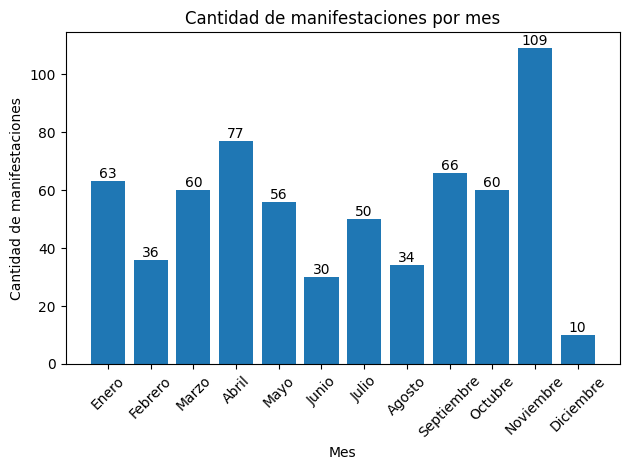

In [330]:
# 🔹 limpiar texto
movilizaciones_tm['Mes'] = (
    movilizaciones_tm['Mes']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.capitalize()
)

# 🔹 orden correcto
orden_meses = [
    'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
    'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'
]

movilizaciones_tm['Mes'] = pd.Categorical(
    movilizaciones_tm['Mes'],
    categories=orden_meses,
    ordered=True
)

# 🔹 agrupar
resumen = (
    movilizaciones_tm
    .groupby('Mes')
    .size()
    .reset_index(name='Cantidad')
)

# 🔥 quitar meses sin datos (opcional pero recomendado)
resumen = resumen[resumen['Cantidad'] > 0]

# 🔹 graficar
plt.figure()

plt.bar(resumen['Mes'], resumen['Cantidad'])

plt.xlabel('Mes')
plt.ylabel('Cantidad de manifestaciones')
plt.title('Cantidad de manifestaciones por mes')

plt.xticks(rotation=45)

# etiquetas
for i, v in enumerate(resumen['Cantidad']):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Filtrar los meses de mayo y junio

In [331]:
movilizaciones_tm_filtro = movilizaciones_tm[
    movilizaciones_tm['Mes'].isin(['Mayo', 'Junio', 'Julio'])
]

movilizaciones_tm_filtro.head(3)

,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,cenefa_fin,nombre_fin,via_fin,direccion_bandera_fin,localidad_fin,longitud_fin,latitud_fin,Fecha_novedad,hora_novedad,Franja
236,GMOVIL ENGATIVA,2022-05-01 10:25:00,[1099] 359,NaN,507146.0,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,Autorización de Desvío / 01-05-2022 /ID 15331/...,NaN,...,111A00,C.C. Terraza Pasteur,Cl 24,CL 24 - KR 5,Santa Fe,-74.069147,4.609356,2022-05-01,10:25:00,10
237,GMOVIL ENGATIVA,2022-05-01 10:26:00,[1103] SE10,504140.0,507116.0,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,Autorización de Desvío / 01-05-2022 /ID 15334/...,NaN,...,096A00,Br. La Alameda,AK 13,AK 13 - CL 20,Santa Fe,-74.074573,4.609007,2022-05-01,10:26:00,10
238,GMOVIL ENGATIVA,2022-05-01 10:48:00,[1099] 359,504349.0,506528.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15370/...,NaN,...,381A00,Br. Pardo Rubio,KR 7,AK 7 - CL 46,Chapinero,-74.063763,4.633213,2022-05-01,10:48:00,10


In [332]:
movilizaciones_tm_filtro['Fecha_extraida'] = pd.to_datetime(
    movilizaciones_tm_filtro['Fecha_extraida'],
    format='mixed',
    dayfirst=True
)

# Copia de la columna
col = base_mov['Fecha_Inicio']

# Crear columna vacía
base_mov['Fecha_Inicio'] = pd.NaT

# 🔹 1. Detectar numéricos (Excel)
mask_num = col.astype(str).str.match(r'^\d+$')

base_mov.loc[mask_num, 'Fecha_Inicio'] = pd.to_datetime(
    col[mask_num].astype(float),
    unit='D',
    origin='1899-12-30'
)

# 🔹 2. Detectar texto (fechas normales)
mask_txt = ~mask_num

base_mov.loc[mask_txt, 'Fecha_Inicio'] = pd.to_datetime(
    col[mask_txt],
    format='mixed',
    dayfirst=True
)

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1515904232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm_filtro['Fecha_extraida'] = pd.to_datetime(


In [333]:
#Llevar tipo día a iri

def calcular_posicion(fecha):
    
    filtro = (
        (base_mov['Fecha_Inicio'] == fecha)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not base_mov.loc[filtro].empty:
        # Obtener el primer valor
        Tipo_día = base_mov.loc[filtro, 'Categoría_Tipo_Evento'].iloc[0]
        return Tipo_día  if not pd.isna(Tipo_día ) else None  
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
movilizaciones_tm_filtro['Categoría_Tipo_Evento'] = movilizaciones_tm_filtro.apply(
    lambda row: calcular_posicion(
        row['Fecha_extraida']
    ),
    axis=1
)

movilizaciones_tm_filtro.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1391798965.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm_filtro['Categoría_Tipo_Evento'] = movilizaciones_tm_filtro.apply(


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,nombre_fin,via_fin,direccion_bandera_fin,localidad_fin,longitud_fin,latitud_fin,Fecha_novedad,hora_novedad,Franja,Categoría_Tipo_Evento
236,GMOVIL ENGATIVA,2022-05-01 10:25:00,[1099] 359,NaN,507146.0,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,Autorización de Desvío / 01-05-2022 /ID 15331/...,NaN,...,C.C. Terraza Pasteur,Cl 24,CL 24 - KR 5,Santa Fe,-74.069147,4.609356,2022-05-01,10:25:00,10,Otros Eventos
237,GMOVIL ENGATIVA,2022-05-01 10:26:00,[1103] SE10,504140.0,507116.0,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,Autorización de Desvío / 01-05-2022 /ID 15334/...,NaN,...,Br. La Alameda,AK 13,AK 13 - CL 20,Santa Fe,-74.074573,4.609007,2022-05-01,10:26:00,10,Otros Eventos
238,GMOVIL ENGATIVA,2022-05-01 10:48:00,[1099] 359,504349.0,506528.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15370/...,NaN,...,Br. Pardo Rubio,KR 7,AK 7 - CL 46,Chapinero,-74.063763,4.633213,2022-05-01,10:48:00,10,Otros Eventos
239,GMOVIL ENGATIVA,2022-05-01 10:48:00,[1103] SE10,504402.0,507407.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15359/...,NaN,...,Br. Teusaquillo,AC 32,AC 32 - AV. Caracas,Teusaquillo,-74.071039,4.620847,2022-05-01,10:48:00,10,Otros Eventos
240,GMOVIL ENGATIVA,2022-05-01 10:50:00,[1407] KL307,500022.0,507530.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15364/...,NaN,...,C.C. Calima,AC 19,AC 19 - AK 27,Los Mártires,-74.086112,4.616622,2022-05-01,10:50:00,10,Otros Eventos


In [334]:
#Llevar tipo día a iri

def calcular_posicion(fecha):
    
    filtro = (
        (base_mov['Fecha_Inicio'] == fecha)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not base_mov.loc[filtro].empty:
        # Obtener el primer valor
        Tipo_día = base_mov.loc[filtro, 'Tipo_ Acompanamiento'].iloc[0]
        return Tipo_día  if not pd.isna(Tipo_día ) else None  
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
movilizaciones_tm_filtro['Tipo_ Acompanamiento'] = movilizaciones_tm_filtro.apply(
    lambda row: calcular_posicion(
        row['Fecha_extraida']
    ),
    axis=1
)

movilizaciones_tm_filtro.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\298417939.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm_filtro['Tipo_ Acompanamiento'] = movilizaciones_tm_filtro.apply(


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,via_fin,direccion_bandera_fin,localidad_fin,longitud_fin,latitud_fin,Fecha_novedad,hora_novedad,Franja,Categoría_Tipo_Evento,Tipo_ Acompanamiento
236,GMOVIL ENGATIVA,2022-05-01 10:25:00,[1099] 359,NaN,507146.0,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,Autorización de Desvío / 01-05-2022 /ID 15331/...,NaN,...,Cl 24,CL 24 - KR 5,Santa Fe,-74.069147,4.609356,2022-05-01,10:25:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas
237,GMOVIL ENGATIVA,2022-05-01 10:26:00,[1103] SE10,504140.0,507116.0,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,Autorización de Desvío / 01-05-2022 /ID 15334/...,NaN,...,AK 13,AK 13 - CL 20,Santa Fe,-74.074573,4.609007,2022-05-01,10:26:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas
238,GMOVIL ENGATIVA,2022-05-01 10:48:00,[1099] 359,504349.0,506528.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15370/...,NaN,...,KR 7,AK 7 - CL 46,Chapinero,-74.063763,4.633213,2022-05-01,10:48:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas
239,GMOVIL ENGATIVA,2022-05-01 10:48:00,[1103] SE10,504402.0,507407.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15359/...,NaN,...,AC 32,AC 32 - AV. Caracas,Teusaquillo,-74.071039,4.620847,2022-05-01,10:48:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas
240,GMOVIL ENGATIVA,2022-05-01 10:50:00,[1407] KL307,500022.0,507530.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15364/...,NaN,...,AC 19,AC 19 - AK 27,Los Mártires,-74.086112,4.616622,2022-05-01,10:50:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas


In [335]:
#Llevar tipo día a iri

def calcular_posicion(fecha):
    
    filtro = (
        (base_mov['Fecha_Inicio'] == fecha)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not base_mov.loc[filtro].empty:
        # Obtener el primer valor
        Tipo_día = base_mov.loc[filtro, 'Identidad'].iloc[0]
        return Tipo_día  if not pd.isna(Tipo_día ) else None  
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
movilizaciones_tm_filtro['Identidad'] = movilizaciones_tm_filtro.apply(
    lambda row: calcular_posicion(
        row['Fecha_extraida']
    ),
    axis=1
)

movilizaciones_tm_filtro.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1994045580.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm_filtro['Identidad'] = movilizaciones_tm_filtro.apply(


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,direccion_bandera_fin,localidad_fin,longitud_fin,latitud_fin,Fecha_novedad,hora_novedad,Franja,Categoría_Tipo_Evento,Tipo_ Acompanamiento,Identidad
236,GMOVIL ENGATIVA,2022-05-01 10:25:00,[1099] 359,NaN,507146.0,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,Autorización de Desvío / 01-05-2022 /ID 15331/...,NaN,...,CL 24 - KR 5,Santa Fe,-74.069147,4.609356,2022-05-01,10:25:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ..."
237,GMOVIL ENGATIVA,2022-05-01 10:26:00,[1103] SE10,504140.0,507116.0,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,Autorización de Desvío / 01-05-2022 /ID 15334/...,NaN,...,AK 13 - CL 20,Santa Fe,-74.074573,4.609007,2022-05-01,10:26:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ..."
238,GMOVIL ENGATIVA,2022-05-01 10:48:00,[1099] 359,504349.0,506528.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15370/...,NaN,...,AK 7 - CL 46,Chapinero,-74.063763,4.633213,2022-05-01,10:48:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ..."
239,GMOVIL ENGATIVA,2022-05-01 10:48:00,[1103] SE10,504402.0,507407.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15359/...,NaN,...,AC 32 - AV. Caracas,Teusaquillo,-74.071039,4.620847,2022-05-01,10:48:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ..."
240,GMOVIL ENGATIVA,2022-05-01 10:50:00,[1407] KL307,500022.0,507530.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15364/...,NaN,...,AC 19 - AK 27,Los Mártires,-74.086112,4.616622,2022-05-01,10:50:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ..."


In [336]:
#Llevar tipo día a iri

def calcular_posicion(fecha):
    
    filtro = (
        (base_mov['Fecha_Inicio'] == fecha)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not base_mov.loc[filtro].empty:
        # Obtener el primer valor
        Tipo_día = base_mov.loc[filtro, 'Nombre_Actor_Organizado'].iloc[0]
        return Tipo_día  if not pd.isna(Tipo_día ) else None  
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
movilizaciones_tm_filtro['Nombre_Actor_Organizado'] = movilizaciones_tm_filtro.apply(
    lambda row: calcular_posicion(
        row['Fecha_extraida']
    ),
    axis=1
)

movilizaciones_tm_filtro.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\454378752.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm_filtro['Nombre_Actor_Organizado'] = movilizaciones_tm_filtro.apply(


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,localidad_fin,longitud_fin,latitud_fin,Fecha_novedad,hora_novedad,Franja,Categoría_Tipo_Evento,Tipo_ Acompanamiento,Identidad,Nombre_Actor_Organizado
236,GMOVIL ENGATIVA,2022-05-01 10:25:00,[1099] 359,NaN,507146.0,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,Autorización de Desvío / 01-05-2022 /ID 15331/...,NaN,...,Santa Fe,-74.069147,4.609356,2022-05-01,10:25:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ...",COMUNIDAD INDÍGENA EMBERA KATIO Y EMBERA CHAMÍ...
237,GMOVIL ENGATIVA,2022-05-01 10:26:00,[1103] SE10,504140.0,507116.0,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,Autorización de Desvío / 01-05-2022 /ID 15334/...,NaN,...,Santa Fe,-74.074573,4.609007,2022-05-01,10:26:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ...",COMUNIDAD INDÍGENA EMBERA KATIO Y EMBERA CHAMÍ...
238,GMOVIL ENGATIVA,2022-05-01 10:48:00,[1099] 359,504349.0,506528.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15370/...,NaN,...,Chapinero,-74.063763,4.633213,2022-05-01,10:48:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ...",COMUNIDAD INDÍGENA EMBERA KATIO Y EMBERA CHAMÍ...
239,GMOVIL ENGATIVA,2022-05-01 10:48:00,[1103] SE10,504402.0,507407.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15359/...,NaN,...,Teusaquillo,-74.071039,4.620847,2022-05-01,10:48:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ...",COMUNIDAD INDÍGENA EMBERA KATIO Y EMBERA CHAMÍ...
240,GMOVIL ENGATIVA,2022-05-01 10:50:00,[1407] KL307,500022.0,507530.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15364/...,NaN,...,Los Mártires,-74.086112,4.616622,2022-05-01,10:50:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ...",COMUNIDAD INDÍGENA EMBERA KATIO Y EMBERA CHAMÍ...


In [337]:
#Llevar tipo día a iri

def calcular_posicion(fecha):
    
    filtro = (
        (base_mov['Fecha_Inicio'] == fecha)
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not base_mov.loc[filtro].empty:
        # Obtener el primer valor
        Tipo_día = base_mov.loc[filtro, 'Aforo'].iloc[0]
        return Tipo_día  if not pd.isna(Tipo_día ) else None  
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
movilizaciones_tm_filtro['Aforo'] = movilizaciones_tm_filtro.apply(
    lambda row: calcular_posicion(
        row['Fecha_extraida']
    ),
    axis=1
)

movilizaciones_tm_filtro.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_16260\1896243585.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movilizaciones_tm_filtro['Aforo'] = movilizaciones_tm_filtro.apply(


,Empresa,Fecha,Linea,Vehiculo,Conductor,Tipo,Subtipo,Subsubtipo,Observaciones,Parametros,...,longitud_fin,latitud_fin,Fecha_novedad,hora_novedad,Franja,Categoría_Tipo_Evento,Tipo_ Acompanamiento,Identidad,Nombre_Actor_Organizado,Aforo
236,GMOVIL ENGATIVA,2022-05-01 10:25:00,[1099] 359,NaN,507146.0,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,Autorización de Desvío / 01-05-2022 /ID 15331/...,NaN,...,-74.069147,4.609356,2022-05-01,10:25:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ...",COMUNIDAD INDÍGENA EMBERA KATIO Y EMBERA CHAMÍ...,365
237,GMOVIL ENGATIVA,2022-05-01 10:26:00,[1103] SE10,504140.0,507116.0,INTERRUPCION DE SERVICIO ZONAL,DESVIO BUS ZONAL,GENERAL,Autorización de Desvío / 01-05-2022 /ID 15334/...,NaN,...,-74.074573,4.609007,2022-05-01,10:26:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ...",COMUNIDAD INDÍGENA EMBERA KATIO Y EMBERA CHAMÍ...,365
238,GMOVIL ENGATIVA,2022-05-01 10:48:00,[1099] 359,504349.0,506528.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15370/...,NaN,...,-74.063763,4.633213,2022-05-01,10:48:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ...",COMUNIDAD INDÍGENA EMBERA KATIO Y EMBERA CHAMÍ...,365
239,GMOVIL ENGATIVA,2022-05-01 10:48:00,[1103] SE10,504402.0,507407.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15359/...,NaN,...,-74.071039,4.620847,2022-05-01,10:48:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ...",COMUNIDAD INDÍGENA EMBERA KATIO Y EMBERA CHAMÍ...,365
240,GMOVIL ENGATIVA,2022-05-01 10:50:00,[1407] KL307,500022.0,507530.0,INTERRUPCION DE SERVICIO ZONAL,MANIFESTACION,INTERRUPCIÓN DE SERVICIO ZONAL POR MANIFESTACIÓN,Autorización de Desvío / 01-05-2022 /ID 15364/...,NaN,...,-74.086112,4.616622,2022-05-01,10:50:00,10,Otros Eventos,Alcaldía Local/Otras entidades públicas,"COMUNIDAD ETNICA, INSTITUCIÓN PÚBLICA/ENTIDAD ...",COMUNIDAD INDÍGENA EMBERA KATIO Y EMBERA CHAMÍ...,365


In [338]:
pip install folium

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [339]:
import folium
from folium.plugins import HeatMap

# Filtrar coordenadas válidas
df_mapa_ini = movilizaciones_tm[
    (movilizaciones_tm["latitud_ini"] != 0) &
    (movilizaciones_tm["longitud_ini"] != 0)
]

# Crear lista de coordenadas
coordenadas_ini = df_mapa_ini[["latitud_ini", "longitud_ini"]].values.tolist()

# Crear mapa centrado en Bogotá
mapa = folium.Map(
    location=[4.65, -74.10],
    zoom_start=11
)

# Agregar heatmap
HeatMap(coordenadas_ini).add_to(mapa)

mapa

In [340]:
mapa.save("mapa.html")

In [341]:
df_mapa_fin = movilizaciones_tm[
    (movilizaciones_tm["latitud_fin"] != 0) &
    (movilizaciones_tm["longitud_fin"] != 0)
]

coordenadas_fin = df_mapa_fin[["latitud_fin", "longitud_fin"]].values.tolist()

mapa_fin = folium.Map(
    location=[4.65, -74.10],
    zoom_start=11
)

HeatMap(coordenadas_fin).add_to(mapa_fin)

mapa_fin

In [342]:
mapa.save("mapa_calor.html")

In [343]:
maestro_paradas.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Rutas_puntos_críticos/paradas.csv', index=False, sep=';')

In [344]:
movilizaciones_tm.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Rutas_puntos_críticos/movilizaciones_2022.csv', index=False, sep=';')

In [345]:
movilizaciones_tm_filtro.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Rutas_puntos_críticos/movilizaciones_may_jul_2022.csv', index=False, sep=';')